<a href="https://colab.research.google.com/github/Irtisam99/Data_Model_Training_Pipeline/blob/main/data_model_and_trainining_pipeline_for_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
"""
Objectives:
1. Develop a data processing pipeline
2. Use torch built in layers to create a deep feed foward neural network
3. Training Techniques: Checkpointing,training,evaluation,learning rate scheduling etc.
"""

import torch
from torchvision import transforms
import pandas as pd
import os
import torch.nn as nn

In [20]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
ROOT_DIR='/content/drive/MyDrive/BongoDev'
DATA_DIR=os.path.join(ROOT_DIR,'Pipeline_dataset')

dataset_path=os.path.join(DATA_DIR,'digit_train.csv')

In [23]:
data=pd.read_csv(dataset_path)
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
"""
Pixels 784
Label 1
"""
len(data.columns)

785

In [25]:
idx=3
pixels=data.iloc[idx].values[1:].astype('float32')
label=data.iloc[idx].values[0]

print(pixels.shape,label)

(784,) 4


In [26]:
print(type(pixels))
print(type(label))

<class 'numpy.ndarray'>
<class 'numpy.int64'>


In [27]:
pixels=torch.tensor(pixels)
label=torch.tensor(label)
print(pixels[200:220])
print(label)

tensor([  0.,   0.,   0., 242., 155.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,  27., 254.,  63.,   0.,   0.,   0.,   0.])
tensor(4)


In [28]:
"""
Each image has three properties: channel, height, width
Channel x H x W

Grayscale: No of channels is 1
RGB: No of channels is 3
"""

pixels=pixels.reshape(28,28).unsqueeze(0)  #from 1D vector to a image shaped matrix
print(pixels.shape)

torch.Size([1, 28, 28])


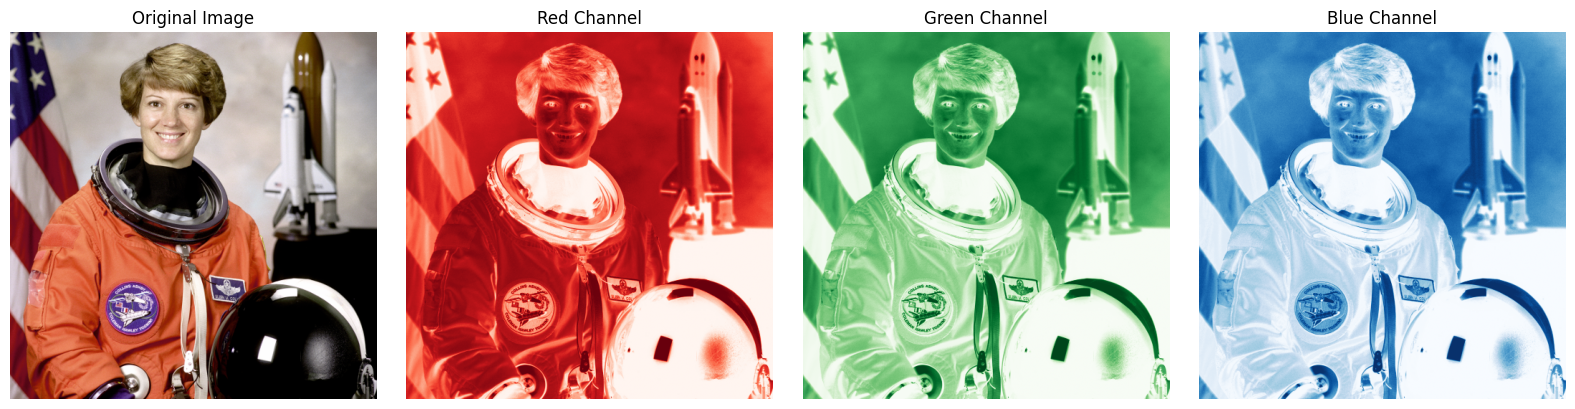

In [29]:
import matplotlib.pyplot as plt
from skimage import data

# Load a built-in RGB image
img = data.astronaut()

# Split into R, G, B channels
R = img[:, :, 0]  # img[width,height,channel]
G = img[:, :, 1]
B = img[:, :, 2]

fig, axs = plt.subplots(1, 4, figsize=(16, 4))

axs[0].imshow(img)
axs[0].set_title('Original Image')
axs[0].axis('off')

axs[1].imshow(R,cmap='Reds')
axs[1].set_title('Red Channel')
axs[1].axis('off')

axs[2].imshow(G,cmap='Greens')
axs[2].set_title('Green Channel')
axs[2].axis('off')

axs[3].imshow(B,cmap='Blues')
axs[3].set_title('Blue Channel')
axs[3].axis('off')

plt.tight_layout()
plt.show()

In [30]:
pixels_transformation=transforms.Compose([
    transforms.Normalize(
        mean=torch.tensor([0.1307]),
        std=torch.tensor([0.3081])
    )
])
pixels=pixels_transformation(pixels)

In [31]:
"""
How to process a single example
pixels,label=example
converts them into tensor
pixels reshape into image size
pixel transformation
""";

In [32]:
""" DATASET CLASS """   # How to process a individual input --
from torch.utils.data import Dataset
class DigitDataset(Dataset):
  def __init__(self,filepath,transform):
    self.data=pd.read_csv(filepath)
    self.transform=transform

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    """Process a single example in the dataset """
    pixels=self.data.iloc[idx].values[1:].astype('float32')
    label=int(self.data.iloc[idx].values[0])

    pixels=torch.tensor(pixels)
    label=torch.tensor(label)

    pixels=pixels.reshape(28,28).unsqueeze(0)
    if self.transform:
      pixels=self.transform(pixels)

    #return pixels,label

    return{
        'pixels':pixels,
        'label':label,
        'date':'10-5-2026'
    }



In [33]:
dataset=DigitDataset(dataset_path,
                     pixels_transformation)

In [34]:
from torch.utils.data import random_split

torch.manual_seed(42)

train_size=int(0.7*len(dataset))
val_size=int(0.15*len(dataset))
test_size=len(dataset)-train_size-val_size

train_dataset,val_dataset,test_dataset=random_split(dataset=dataset,
                                                    lengths=[train_size,val_size,test_size])



In [35]:
from torch.utils.data import DataLoader

# DATA LOADER CREATES LIST OF INDEXES
train_loader=DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size = 64,
    shuffle = False
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size=16,
    shuffle = False
)

In [36]:
# BATCH SIZE =32 , EACH TIME LIST OF 32 INDICES AT A TIME
#for pixels,labels in train_loader:
  #print(pixels.shape)
  #print(labels.shape)
  #break

for batch in train_loader:
  print(type(batch))
  print(batch.keys())
  pixels=batch['pixels']
  labels=batch['label']
  dates=batch['date']

  print(pixels.shape)
  print(labels.shape)
  print(labels)
  break


<class 'dict'>
dict_keys(['pixels', 'label', 'date'])
torch.Size([32, 1, 28, 28])
torch.Size([32])
tensor([6, 0, 0, 1, 7, 7, 1, 4, 0, 2, 1, 1, 5, 9, 2, 4, 3, 8, 6, 7, 2, 4, 1, 7,
        1, 7, 9, 5, 3, 2, 5, 0])


In [37]:
"""
Dataset: __len__,__getitem__
Dataloader:dataset,batch_size=2,shuffle

n=dataset.__len__() #Let us assume there are 7 examples
batch_indices=[1,0,3,4,6,4,5] # Index Value of the examples
batch_indices=[[1,0],  #batch1
                [3,2],  #batch2
                [6,4],  #batch3
                [5]]    #batch4

when run: for batch in train_loader:

Under the hood:
processesd_data={
   'pixels': [],
    'label': [],
    'date': []
}
for idx in batch1:
   processesd_example_dict=dataset.__getitem__(idx)
   processed_data['pixels'].append(processed_example_dict['pixels'])
   processed_data['label'].append(processed_example_dict['label'])
   processed_data['date'].append(processed_example_dict['date'])
return processed_data

"""
class DigitClassifier(nn.Module):
  def __init__(self):
    super(DigitClassifier,self).__init__()
    self.fc1=nn.Linear(28*28,128)
    self.fc2=nn.Linear(128,64)
    self.fc3=nn.Linear(64,10)

  def forward(self,x):
    #print("DEBUG:",type(x))
    #print("DEBUG",x.shape)

    x=x.view(-1,28*28)
    x=self.fc1(x)
    x=torch.relu(x)
    x=self.fc2(x)
    x=torch.relu(x)
    x=self.fc3(x)

    return x



In [38]:
def evaluate_model(model,data_loader,criterion,device):
  model.eval()
  val_loss=0
  accuracy=0
  with torch.no_grad():
    for batch_idx,batch in enumerate(data_loader):
      data=batch['pixels']
      target=batch['label']
      data,target=data.to(device),target.to(device)
      output=model(data)
      loss=criterion(output,target)
      val_loss+=loss.item()

      _,predicted=torch.max(output.data,1)
      accuracy+=(predicted==target).sum().item()

    val_loss /= len(data_loader.dataset)
    accuracy /= len(data_loader.dataset)
  return val_loss,accuracy


In [45]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    device,
    checkpoint_path
):
  model.train()

  best_val_accuracy=0
  patience=3

  #Checkpoints
  checkpoint_dir=os.path.dirname(checkpoint_path)
  if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

  for epoch in range(num_epochs):
    train_loss=0
    for batch_idx,batch in enumerate(train_loader):
      pixel_batch=batch['pixels']
      label_batch=batch['label']
      pixel_batch,label_batch=pixel_batch.to(device),label_batch.to(device)
      optimizer.zero_grad()
      output=model(pixel_batch)
      loss=criterion(output,label_batch)
      loss.backward()
      optimizer.step()
      train_loss+=loss.item()

    train_loss/=len(train_loader.dataset)
    val_loss,val_accuracy=evaluate_model(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=device
    )
    if val_accuracy>best_val_accuracy:
      best_val_accuracy=val_accuracy
      torch.save(model.state_dict(),checkpoint_path)
      print("Best Parameter so far.")
    else:
      """  EARLY STOPPING """
      patience=patience-1
    print(f"epoch [{epoch+1}/{num_epochs}], loss: {train_loss:.4f}", end=" ")
    print(f"val_loss: {val_loss:.4f}", end=" ")
    print(f"val_acc: {val_accuracy:.4f}")

    if patience==0:
      """CALL BACK: EARLY STOPPING"""
      print(f"Model Performance is not improving, Exiting the training.")
      break



In [46]:
model = DigitClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [47]:
folder='/content/drive/MyDrive/BongoDev'
checkpoint_path = os.path.join(
    folder, "checkpoints", "best_model.pth"
)

In [48]:
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path))
    print("Model loaded successfully from checkpoints.")

In [49]:
train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=100,
    device=device,
    checkpoint_path=checkpoint_path,
)

Best Parameter so far.
epoch [1/100], loss: 0.0259 val_loss: 0.0048 val_acc: 0.9132
Best Parameter so far.
epoch [2/100], loss: 0.0079 val_loss: 0.0048 val_acc: 0.9219
Best Parameter so far.
epoch [3/100], loss: 0.0059 val_loss: 0.0033 val_acc: 0.9471
epoch [4/100], loss: 0.0053 val_loss: 0.0030 val_acc: 0.9467
Best Parameter so far.
epoch [5/100], loss: 0.0047 val_loss: 0.0032 val_acc: 0.9489
Best Parameter so far.
epoch [6/100], loss: 0.0047 val_loss: 0.0025 val_acc: 0.9594
epoch [7/100], loss: 0.0045 val_loss: 0.0028 val_acc: 0.9556
epoch [8/100], loss: 0.0043 val_loss: 0.0034 val_acc: 0.9502
Model Performance is not improving, Exiting the training.


In [50]:
model.load_state_dict(torch.load(checkpoint_path))

val_loss, val_acc = evaluate_model(
    model=model,
    data_loader=val_loader,
    criterion=criterion,
    device=device
)

print(f"val_loss: {val_loss:0.4f}, val_acc: {val_acc:0.4f}")

val_loss: 0.0025, val_acc: 0.9594


In [51]:
test_loss, test_accuracy = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

print(f"test_loss: {test_loss:0.4f}, test_acc: {test_accuracy:0.4f}")

test_loss: 0.0131, test_acc: 0.9505


### How Traditional ML Model performs to the same case : Decision Tree

In [52]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

X_train = np.array([data['pixels'].numpy().flatten() for data in train_dataset])
y_train = np.array([data['label'] for data in train_dataset])
X_test = np.array([data['pixels'].numpy().flatten() for data in test_dataset])
y_test = np.array([data['label'] for data in test_dataset])

dt_classifier = DecisionTreeClassifier()
dt_classifier.fit(X_train, y_train)

y_pred = dt_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'DecisionTreeClassifier test accuracy: {accuracy:.2f}')

DecisionTreeClassifier test accuracy: 0.86
